# Alternative Ensemble Analysis Methods

## 1. Reconstruction Independent Component Analysis - RICA

RICA learns a linear transformation a t x f, where t is number of obeservation or trials and f is the number of features to be extracted from population array. The transformation is based on optimizing a nonlinear objective function that roughly balances statistical independence of the output features versus the ability to reconstruct the input data using the output features.

In [1]:
% load data
addpath('matlab','data')
load('calcium_data.mat')
load('stimuli_info.mat')
load ('data_stimsorted.mat')
load('ROI_positions.mat')

In [35]:
%Variables
thrld = 0.25;
fov = 4; % 1 of 8 FOV
tbin = 0.5; % 1 second time bin
stim_onset = 5;
num_rois = numel(fieldnames(dat_sorted{fov}.deNoise_dff));
stimulus = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1', 'blank'};

## Note on Pre-whitening before ICA

Before performing ICA, the input data is usually whitened to remove any correlation. The data is transformed to have zero mean and identity covariance in order to get statistically independent dimensions (neurons): P(A n B) = P(A)P(B).

Forcing all dimensions to have unit variance treats each dimension with equal importance.

With that in mind, it will not be useful to treat all neurons with equal importance, removes the interesting correlations we seek to find. Could think of doing some other pre-processing step that removes "un-important" neurons. 

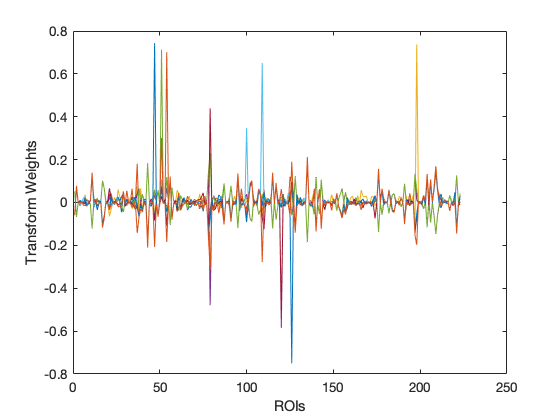

In [288]:
% Get Population Array
t_start = 8;
frameRate = 7.4811;
t_end = t_start + round(tbin*frameRate);

[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,t_start,tbin);
[stim_PA_zscore, mu, sigma] = zscore(stim_PA);

prewhiten_stimPA = prewhiten(stim_PA); % try pre-whitening, no luck 

% Num of Features to Extract 
nfeatures = 9; % Choose 9 to start with, 9 stimuli 
RICAmodel = rica(stim_PA-mu, nfeatures, 'NonGaussianityIndicator', -ones(nfeatures,1)); % subtract mean and indicate original ensembles as non-gaussian


figure(1)
plot(RICAmodel.TransformWeights)
xlabel('ROIs')
ylabel('Transform Weights')

_Notes_:
- stability of features is improved when subtracting mu and specifying sub-gaussian features to be extracted
    - however features are somewhat unstable after succesive runs of the algorithm
    
## Whisker Tuning for Cells in each Feature

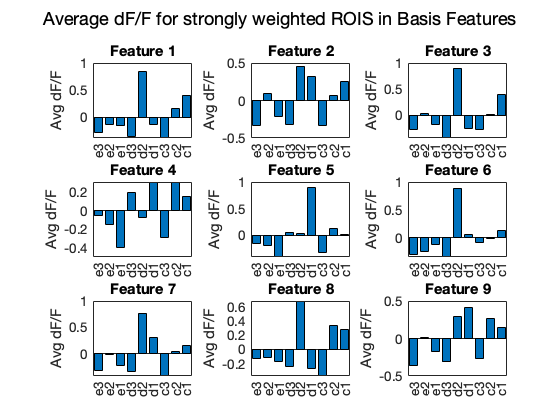

In [290]:
% Whisker Tuning for Cells heavily weighted in PC
cutoff = 0.1;
for PC = 1:size(RICAmodel.TransformWeights,2)
    PC_weights{PC}.rois = find(RICAmodel.TransformWeights(:,PC) > cutoff);
    PC_weights{PC}.dff_max = zeros(length(PC_weights{PC}.rois),9);
    for nrois = 1:length(PC_weights{PC}.rois)
        roi = ['ROI', num2str(PC_weights{PC}.rois(nrois))];
        for stim_num = 1:length(stimulus)-1
            stim = stimulus{stim_num};
            dff_stim = dat_sorted{fov}.deNoise_dff.(roi).(stim);
            PC_weights{PC}.dff_max(nrois,stim_num) = mean(max(dff_stim(:,t_start:t_end),[],2));
        end
    end 
end

%Plot whisker tuning for each ROI weighted strongly in first few PCs  

whiskers = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
x = categorical(whiskers);
x = reordercats(x, whiskers);

% Mean Whisker Receptive Field for ROIs in Cluster

for PC = 1:size(RICAmodel.TransformWeights,2)
    y = zscore(PC_weights{PC}.dff_max,[],2);
    whisk_resp_avg = mean(y,1);
    subplot(3,3,PC)
    bar(x,whisk_resp_avg)
    ylabel('Avg dF/F')
    title(['Feature ', num2str(PC)])
end
sgtitle('Average dF/F for strongly weighted ROIS in Basis Features')

## Ensemble Activity during Single Whisker Deflection Trials

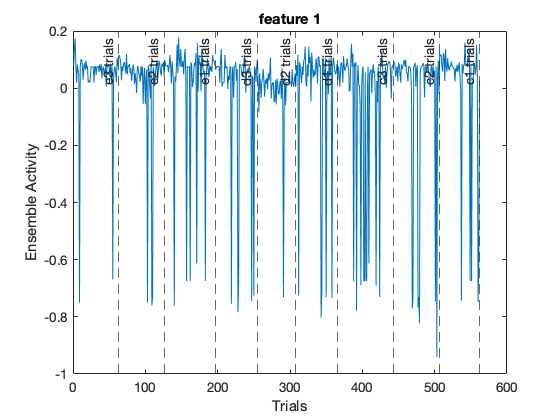

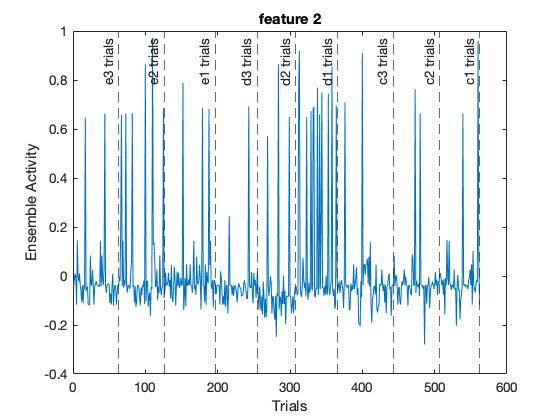

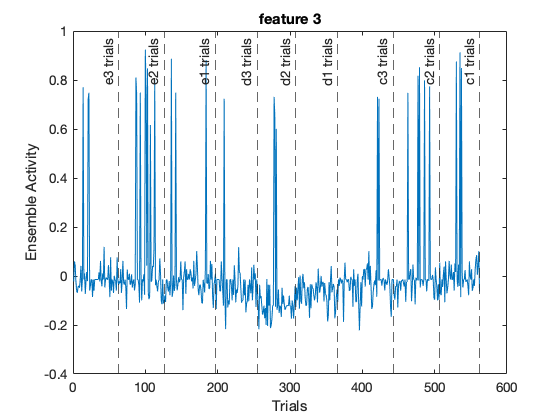

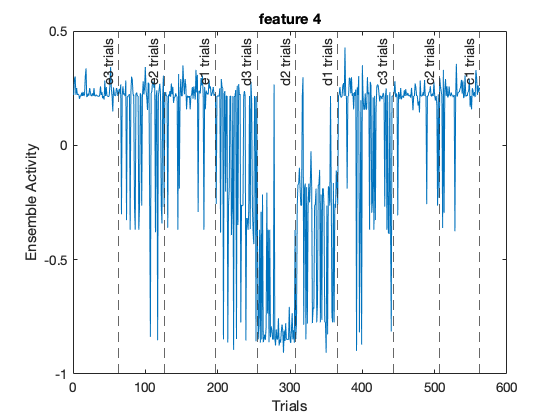

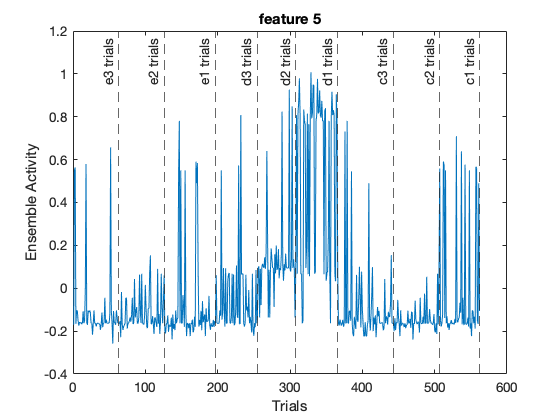

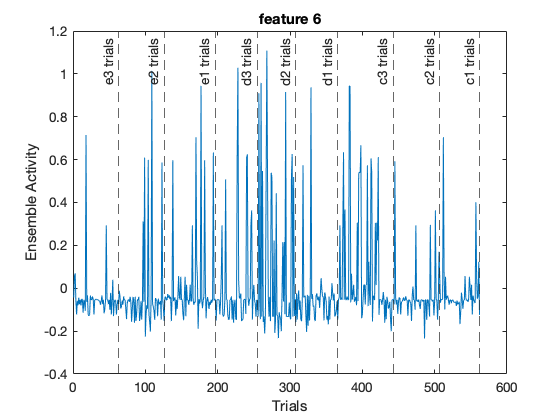

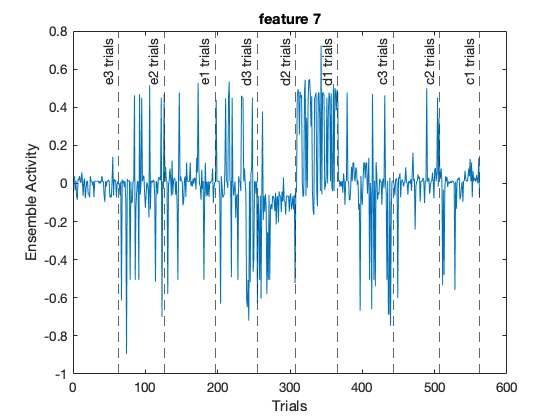

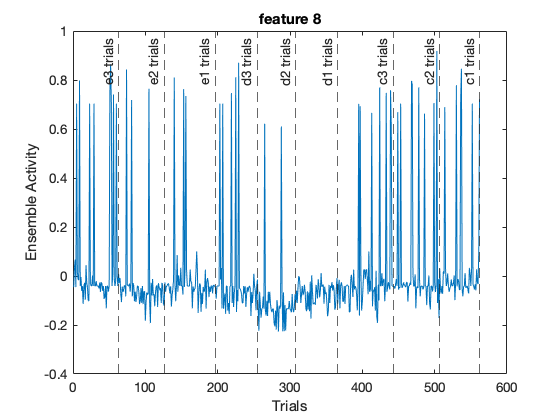

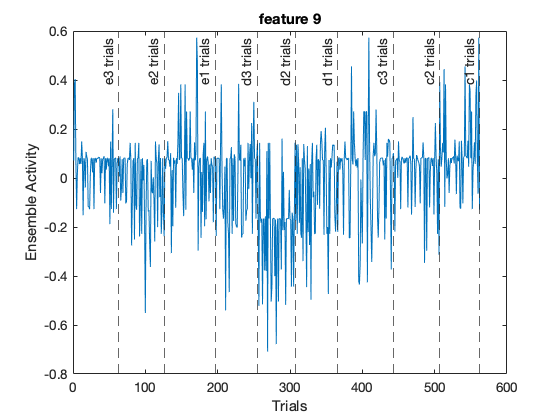

In [310]:
% Map input data into new feature space

ensemble_activity = transform(RICAmodel,stim_PA-mu);
stim_start = cumsum(pa_size);

for features = 1:nfeatures
    figure(features)
    plot(ensemble_activity(:,features))
    xlabel('Trials')
    ylabel('Ensemble Activity')
    for stim = 1: length(stimulus)-1
       xline(stim_start(stim),'--',[stimulus{stim}, ' trials'],'LabelHorizontalAlignment', 'left');
    end
    title(['feature ', num2str(features)])
end

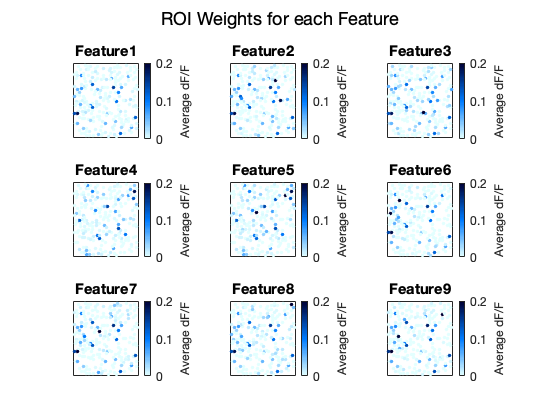

In [294]:
%Plot average dF/F on map of ROIs

% Get ROI Positions 
x_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1);
y_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1);
% x_pst = zeros(num_rois,1);
% y_pst = zeros(num_rois,1);
for i = 1:numel(fields(ROI_position{fov}.ROI_centroids))
    roi = ['ROI', num2str(i)];
    x_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(1);
    y_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(2);
end

for clust = 1:nfeatures
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, RICAmodel.TransformWeights(:,clust), ['Feature',num2str(clust)],8)
    caxis([0,0.2])
    
end
sgtitle('ROI Weights for each Feature')

In [308]:
% D2 Ensemble
PC_weights{1}.rois
PC_weights{3}.rois
PC_weights{6}.rois 
PC_weights{8}.rois


ans =

    11
    56
    95
   115
   135
   176
   204
   209


ans =

    11
    56
    95
   115
   135
   176
   198
   204
   209


ans =

    11
    51
    56
    95
   100
   109
   115
   135
   176
   204
   209


ans =

    11
    47
    56
    95
   115
   135
   176
   204
   209



In [309]:
%D1 Ensemble
PC_weights{5}.rois


ans =

    17
    43
    51
    54
    78
    79
   128
   140
   143
   197
   221



In [ ]:
% Combine Tuning of Cells 


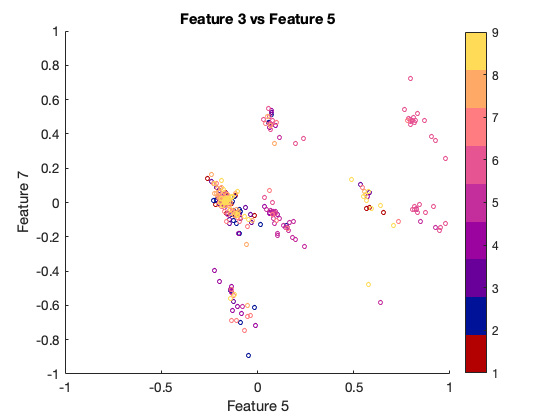

In [312]:

plot_PCAscores(ensemble_activity(:,5),ensemble_activity(:,7), stim_label, 'Feature 3 vs Feature 5')
xlabel('Feature 5')
ylabel('Feature 7')
xlim([-1,1])
ylim([-1,1])

Questions / Concerns
- not sure how to choose number of features? Assume the same number of ensembles as types of stimuli
    - distribution of weight on number of neurons increases with increasing feature number

## 2. Conditional Random Fields - Yuste Lab Method

Save stimului and population array for the analysis

In [170]:
% save data array 
fov = 4;
[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,t_start,tbin);
data = stim_PA;

% save stimulus array 
pa_size = zeros(length(stimulus)-1,1);
stim_array = [];
for stim_num = 1: length(stimulus)-1
    stim = stimulus{stim_num};
    pa_size(stim_num) = length(dat_sorted{fov}.dff.ROI1.(stim));
    stim_indiv = zeros(pa_size(stim_num),length(stimulus)-1);
    stim_indiv(:,stim_num) = ones(pa_size(stim_num),1);
    stim_array = cat(1,stim_array,stim_indiv);
end
stimuli = stim_array;
% save('fov8_9whisk.mat','data','stimuli')